In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple

In [2]:
def set_seed(seed=228):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes
    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])
    vertices = np.array(vertices)
    sampled_points = []
    for i in range(len(vertices) - 1):
        start = vertices[i]
        end = vertices[i+1]
        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start + t * end
            sampled_points.append(point)
    return np.array(sampled_points)

In [3]:
@dataclass
class VPConfig:
    beta_min: float = 0.1
    beta_max: float = 5.0
    cosine_s: float = 0.008
    cosine_t_max: float = 0.98
    eps: float = 1e-3

    hidden_dim: int = 512
    depth: int = 4
    time_embed_max_freq: float = 1000.0

    lr: float = 1e-3
    epochs: int = 800
    batch_size: int = 512
    data_samples: int = 5000
    num_timesteps: int = 1800
    sampler: str = 'heun_ode'

    loss_weight: str = 'uniform'
    schedule: str = 'linear'
    min_snr_gamma: float = 5.0
    loss_weight_clip: float = 100.0
    normalize_loss_weight: bool = True

    seed: int = 42
    force_device: str = None

In [4]:
def vp_alpha_bar(t, config, schedule='linear'):
    if schedule == 'linear':
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        alpha_bar = torch.exp(-int_beta)
    elif schedule == 'cosine':
        t = torch.clamp(t, 0.0, getattr(config, 'cosine_t_max', 1.0 - config.eps))
        s = config.cosine_s
        theta_t = (t + s) / (1.0 + s) * math.pi / 2.0
        theta_0 = torch.tensor(s / (1.0 + s) * math.pi / 2.0, device=t.device, dtype=t.dtype)
        alpha_bar = (torch.cos(theta_t) / torch.cos(theta_0)) ** 2
    return torch.clamp(alpha_bar, min=config.eps ** 2, max=1.0)

def vp_marginal(t, config, schedule='linear'):
    alpha_bar = vp_alpha_bar(t, config, schedule)
    alpha = torch.sqrt(alpha_bar)
    sigma = torch.sqrt(torch.clamp(1.0 - alpha_bar, min=config.eps ** 2))
    return alpha, sigma

def vp_beta(t, config, schedule='linear'):
    if schedule == 'linear':
        return config.beta_min + t * (config.beta_max - config.beta_min)
    if schedule == 'cosine':
        t = torch.clamp(t, 0.0, getattr(config, 'cosine_t_max', 1.0 - config.eps))
        s = config.cosine_s
        theta_t = (t + s) / (1.0 + s) * math.pi / 2.0
        beta = math.pi / (1.0 + s) * torch.tan(theta_t)
        return torch.clamp(beta, min=config.eps, max=999.0)
    raise ValueError(f'Unknown VP schedule: {schedule}')

def vp_loss_weight(t, alpha, sigma, beta, config, mode='uniform'):
    alpha_bar = alpha ** 2
    sigma2 = sigma ** 2
    snr = alpha_bar / torch.clamp(sigma2, min=config.eps ** 2)
    if mode == 'uniform':
        weight = torch.ones_like(t)
    elif mode == 'alpha_bar':
        weight = alpha_bar
    elif mode == 'sigma2':
        weight = sigma2
    elif mode == 'likelihood':
        weight = beta / torch.clamp(sigma2, min=config.eps ** 2)
    elif mode == 'min_snr':
        gamma = torch.full_like(snr, config.min_snr_gamma)
        weight = torch.minimum(snr, gamma) / torch.clamp(snr, min=config.eps ** 2)
    weight = torch.clamp(weight, max=config.loss_weight_clip)
    if config.normalize_loss_weight:
        weight = weight / torch.clamp(weight.mean().detach(), min=config.eps)
    return weight.detach()

In [5]:
class FourierTimeEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.proj = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
        )
    def forward(self, t):
        half_dim = self.config.hidden_dim // 2
        freqs = torch.exp(torch.linspace(0.0, math.log(self.config.time_embed_max_freq), half_dim, device=t.device))
        args = t * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if embedding.shape[1] < self.config.hidden_dim:
            pad = torch.zeros(t.shape[0], self.config.hidden_dim - embedding.shape[1], device=t.device)
            embedding = torch.cat([embedding, pad], dim=1)
        return self.proj(embedding)

class SwiGLUBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, 2 * hidden_dim)
        self.out = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, x):
        gate, value = self.proj(self.norm(x)).chunk(2, dim=1)
        return x + self.out(F.silu(gate) * value)

class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.time_embed = FourierTimeEmbedding(config)
        self.input = nn.Linear(2 + config.hidden_dim, config.hidden_dim)
        self.blocks = nn.ModuleList([SwiGLUBlock(config.hidden_dim) for _ in range(config.depth)])
        self.output = nn.Sequential(
            nn.LayerNorm(config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2),
        )
    def forward(self, x, t):
        t_embed = self.time_embed(t)
        h = self.input(torch.cat([x, t_embed], dim=1))
        for block in self.blocks:
            h = block(h)
        return self.output(h)

In [6]:
class VPSDETrainer:
    def __init__(self, config: VPConfig):
        self.config = config
        set_seed(config.seed)
        self.device = torch.device(config.force_device if config.force_device else ('cuda' if torch.cuda.is_available() else 'cpu'))

        star = generate_star(n_samples=config.data_samples)
        data_raw = torch.tensor(star, dtype=torch.float32)
        self.data_mean = data_raw.mean(dim=0, keepdim=True)
        self.data_std = data_raw.std(dim=0, keepdim=True).clamp(min=config.eps)
        self.data = (data_raw - self.data_mean) / self.data_std

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            t_max = getattr(self.config, 'cosine_t_max', 1.0 - self.config.eps) if self.config.schedule == 'cosine' else 1.0 - self.config.eps
            t = self.config.eps + (t_max - self.config.eps) * torch.rand(batch.shape[0], 1, device=self.device)
            alpha, sigma = vp_marginal(t, self.config, self.config.schedule)
            beta = vp_beta(t, self.config, self.config.schedule)

            z = torch.randn_like(batch)
            x_t = alpha * batch + sigma * z

            pred_z = self.model(x_t, t)
            per_sample_loss = (pred_z - z).pow(2).mean(dim=1)
            weight = vp_loss_weight(t, alpha, sigma, beta, self.config, self.config.loss_weight).squeeze(1)
            loss = (weight * per_sample_loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item() * batch.shape[0]
        return total_loss / len(self.data)

    def run(self, log_every=100):
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            self.history.append(loss)
            if epoch % log_every == 0 or epoch == self.config.epochs - 1:
                print(f'{self.config.schedule:>6} | {self.config.loss_weight:>10} | epoch {epoch:4d} | loss {loss:.6f}')
        return self.history

    def sample(self, num_samples=1000, seed=None):
        device = self.device
        if seed is not None:
            set_seed(seed)
        self.model.eval()
        with torch.no_grad():
            x = torch.randn(num_samples, 2, device=device)
            t_start = getattr(self.config, 'cosine_t_max', 1.0 - self.config.eps) if self.config.schedule == 'cosine' else 1.0 - self.config.eps
            dt = (t_start - self.config.eps) / self.config.num_timesteps

            def score_fn(current_x, current_t):
                _, sigma = vp_marginal(current_t, self.config, self.config.schedule)
                pred_z = self.model(current_x, current_t)
                return -pred_z / torch.clamp(sigma, min=self.config.eps)

            def probability_flow_drift(current_x, current_t):
                beta = vp_beta(current_t, self.config, self.config.schedule)
                score = score_fn(current_x, current_t)
                return 0.5 * beta * current_x + 0.5 * beta * score

            for i in range(self.config.num_timesteps):
                t_value = t_start - i * dt
                t_value = max(t_value, self.config.eps)
                t = torch.full((num_samples, 1), t_value, device=device)
                if self.config.sampler == 'heun_ode':
                    drift = probability_flow_drift(x, t)
                    x_euler = x + drift * dt
                    t_next = torch.full((num_samples, 1), max(t_value - dt, self.config.eps), device=device)
                    drift_next = probability_flow_drift(x_euler, t_next)
                    x = x + 0.5 * (drift + drift_next) * dt
                elif self.config.sampler == 'euler_ode':
                    x = x + probability_flow_drift(x, t) * dt
                elif self.config.sampler == 'reverse_sde':
                    beta = vp_beta(t, self.config, self.config.schedule)
                    drift = 0.5 * beta * x + beta * score_fn(x, t)
                    noise = torch.randn_like(x) if i < self.config.num_timesteps - 1 else torch.zeros_like(x)
                    x = x + drift * dt + torch.sqrt(torch.clamp(beta * dt, min=0.0)) * noise
                else:
                    raise ValueError(f'Unknown sampler: {self.config.sampler}')
            samples = x.cpu() * self.data_std.cpu() + self.data_mean.cpu()
            return samples.numpy()

def star_quality_score(samples, reference_points):
    samples_t = torch.tensor(samples, dtype=torch.float32)
    ref_t = torch.tensor(reference_points, dtype=torch.float32)
    dist = torch.cdist(samples_t, ref_t).min(dim=1).values
    return dist.mean().item()

In [7]:
def run_experiments(schedules, loss_weights, config_template, num_samples=1000):
    results = []
    ref_points = generate_star(n_samples=config_template.data_samples)
    for schedule in schedules:
        for loss_weight in loss_weights:
            print(f'\nschedule={schedule}, loss_weight={loss_weight}')
            cfg = VPConfig(**config_template.__dict__)
            cfg.schedule = schedule
            cfg.loss_weight = loss_weight
            trainer = VPSDETrainer(cfg)
            trainer.run()
            samples = trainer.sample(num_samples=num_samples, seed=cfg.seed+123)
            score = star_quality_score(samples, ref_points)
            print(f'Quality score: {score:.6f}')
            results.append({
                'schedule': schedule,
                'loss_weight': loss_weight,
                'trainer': trainer,
                'samples': samples,
                'score': score,
                'history': trainer.history,
            })
    return results

In [8]:
def plot_results(results, reference_points):
    plt.figure(figsize=(10,5))
    for res in results:
        label = f"{res['schedule']} / {res['loss_weight']}"
        plt.plot(res['history'], label=label)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.show()

    best = sorted(results, key=lambda x: x['score'])[:3]
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    for ax, res in zip(axes, best):
        ax.scatter(reference_points[:,0], reference_points[:,1], s=2, alpha=0.15, color='black')
        ax.scatter(res['samples'][:,0], res['samples'][:,1], s=8, alpha=0.65)
        ax.set_title(f"{res['schedule']} / {res['loss_weight']}\nscore={res['score']:.4f}")
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


schedule=linear, loss_weight=uniform
linear |    uniform | epoch    0 | loss 1.257578
linear |    uniform | epoch  100 | loss 0.473529
linear |    uniform | epoch  200 | loss 0.448133
linear |    uniform | epoch  300 | loss 0.449781
linear |    uniform | epoch  400 | loss 0.437748
linear |    uniform | epoch  500 | loss 0.454476
linear |    uniform | epoch  600 | loss 0.444909
linear |    uniform | epoch  700 | loss 0.432696
linear |    uniform | epoch  799 | loss 0.457840
Quality score: 0.014849

schedule=linear, loss_weight=alpha_bar
linear |  alpha_bar | epoch    0 | loss 1.345641
linear |  alpha_bar | epoch  100 | loss 0.614094
linear |  alpha_bar | epoch  200 | loss 0.559332
linear |  alpha_bar | epoch  300 | loss 0.572464
linear |  alpha_bar | epoch  400 | loss 0.559896
linear |  alpha_bar | epoch  500 | loss 0.587615
linear |  alpha_bar | epoch  600 | loss 0.559579
linear |  alpha_bar | epoch  700 | loss 0.540922
linear |  alpha_bar | epoch  799 | loss 0.577116
Quality score: 0

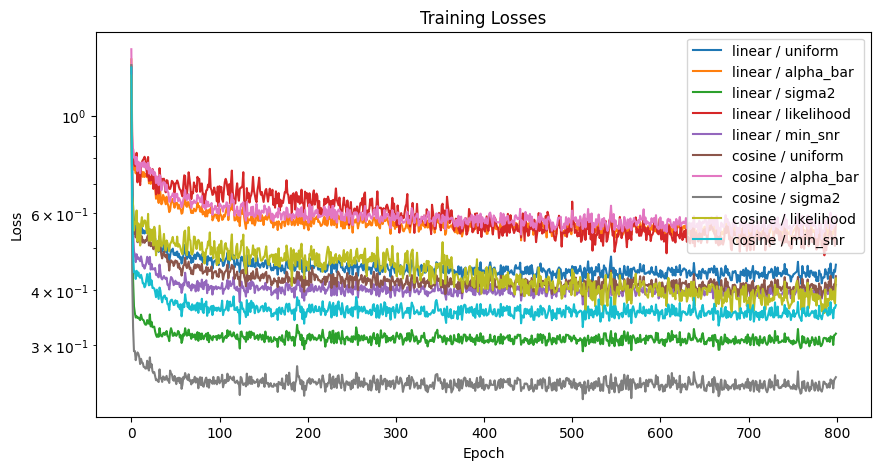

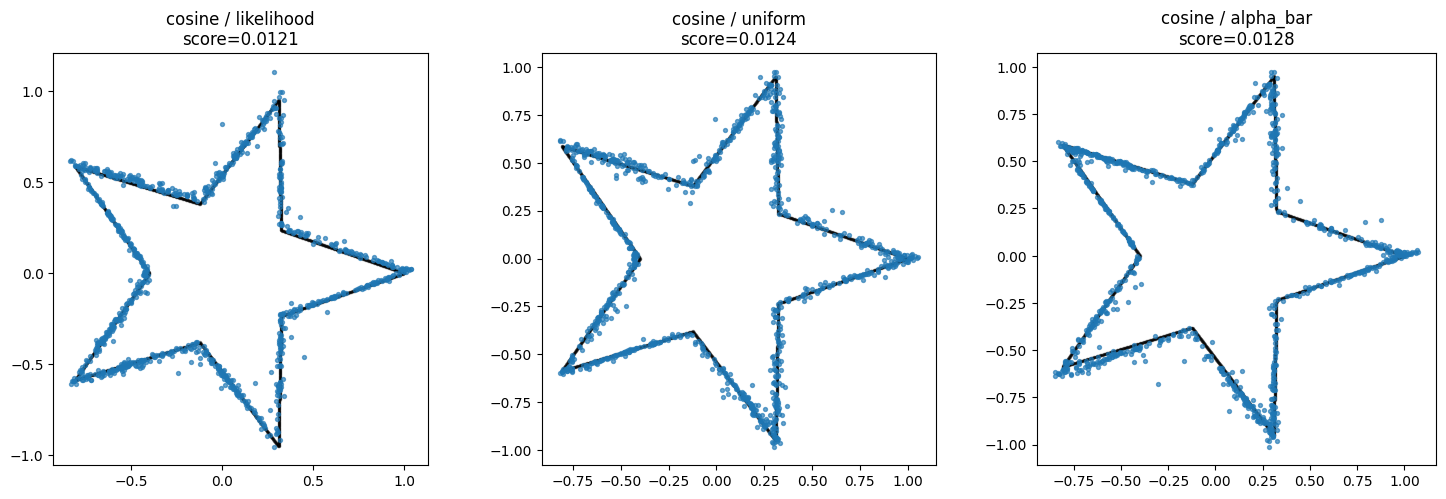

In [9]:
schedules = ('linear', 'cosine')
loss_weights = ('uniform', 'alpha_bar', 'sigma2', 'likelihood', 'min_snr')
config = VPConfig()

results = run_experiments(schedules, loss_weights, config, num_samples=1000)

ref_points = generate_star(n_samples=config.data_samples)
plot_results(results, ref_points)